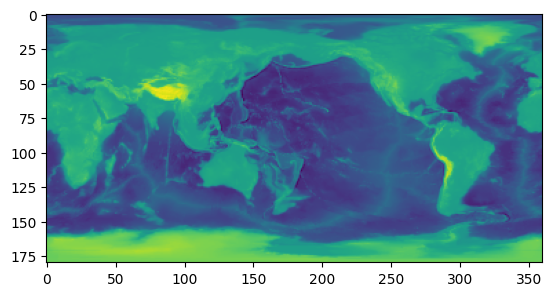

In [1]:
import matplotlib.pyplot as plt
import numpy as np
H = np.loadtxt('topography_180x360_grid.txt')
plt.imshow(H)
plt.show()

Write a pair of nested for loops that print the geographic latitude and longitude as well as the
elevation for every data point.

In [ ]:
# 180x360
for i in range(0, 179):
  for j in range (0, 359):
    print(i)
    print(j)
    print(H[i, j])

Streaming output truncated to the last 5000 lines.
128
2820.0
174
129
2785.0
174
130
2785.0
174
131
2782.0
174
132
2766.0
174
133
2763.0
174
134
2747.0
174
135
2745.0
174
136
2737.0
174
137
2734.0
174
138
2724.0
174
139
2766.0
174
140
2757.0
174
141
2757.0
174
142
2757.0
174
143
2757.0
174
144
2757.0
174
145
2757.0
174
146
2756.0
174
147
2750.0
174
148
2721.0
174
149
2754.0
174
150
2731.0
174
151
2560.0
174
152
2471.0
174
153
2463.0
174
154
2410.0
174
155
2410.0
174
156
2402.0
174
157
2377.0
174
158
2370.0
174
159
2321.0
174
160
2274.0
174
161
2233.0
174
162
2278.0
174
163
2158.0
174
164
2312.0
174
165
2413.0
174
166
2054.0
174
167
1646.0
174
168
1442.0
174
169
1450.0
174
170
1475.0
174
171
1622.0
174
172
2204.0
174
173
2352.0
174
174
2144.0
174
175
2333.0
174
176
1870.0
174
177
1320.0
174
178
1120.0
174
179
1308.0
174
180
1264.0
174
181
1243.0
174
182
992.0
174
183
539.0
174
184
714.0
174
185
990.0
174
186
886.0
174
187
757.0
174
188
630.0
174
189
597.0
174
190
533.0
174
191
296.0
174

Determine the size of the patch that corresponds to every data point. Sum them all up and test
if you approximately reproduce the analytical value $A=4\pi R^2$

In [2]:
# Compare sum of sin(theta)*d(psi) and 4pi=12.56
area = 0
for i in range(0,179):
  for j in range(0,359):
    darea = np.sin(np.radians(i))*(np.pi/180)**2
    area += darea

print(area)

12.566051618120426


Now we actually want to compute the fraction of the Earth's surface that is covered by water.
This requires an if statement because we only want to add those areas where the elevation is
below zero.

In [ ]:
area = 0
R = 6371  # Earth's approximate radius in km

for i in range(0,179):
  for j in range(0,359):
    # if the elevation is below zero -> calculate it
    if H[i, j] < 0:
      # sin(theta)*d(psi) -> sum all of them -> times by R^2 after the loop
      darea = np.sin(np.radians(i))*(np.pi/180)**2
      # can also use this approach: by directly times it by R^2 in the loop
      # darea = (np.sin(np.radians(i))*(np.pi/180)**2)*(R)**2
      area += darea

area *= (R)**2
print(area)

361073491.4988786


Now compute the volume of the oceans by adding height times area for all patches where
there is water.

In [ ]:
# METHOD 1: FROM PROFESSOR
volume = 0
R = 6371  # Earth's approximate radius in km

for i in range(0,179):
  for j in range(0,359):
    # if the elevation is below zero ...
    if H[i, j] < 0:
      # formula: sin(theta)*d(psi)*height -> the height is minus (from sea's surface to the bottom)
      dvol = np.sin(np.radians(i))*(np.pi/180)**2*H[i,j]
      # sum the volume
      volume += dvol

# to anticipate the negative value -> times it with minus
# then, based on the formula, times it with R^2
# finally, divide it by 1000 to convert m to km (to match the R)
volume *= -(R)**2/1000

print(volume)

1334915096.9747903


In [ ]:
# METHOD 2: FROM ME
volume = 0
R = 6371  # Earth's approximate radius in km

for i in range(0,179):
  for j in range(0,359):
    # Use an if statement to check if the elevation is below zero
    if H[i, j] < 0:
      # calculate using the regular formula -> sin(theta)*d(psi)
      darea = np.sin(np.radians(i))*(np.pi/180)**2
      # then, times it with R^2 to find the area
      darea *= (R)**2
      # because the height is minus, put abs() to make it stay positive
      height = abs(H[i, j]) / 1000.0
      # times the area with the height based on the instruction to obtain volume
      # sum the volume
      volume += height * darea

print(volume)

1334915096.9747863
